In [1]:
import os
import pathlib
import sys


DNSCBOR_EVAL_DIR = pathlib.Path.cwd()
os.environ["DNSCBOR_EVAL_DIR"] = str(DNSCBOR_EVAL_DIR)

if str((DNSCBOR_EVAL_DIR / "..").absolute()) not in sys.path:
    sys.path.append(str((DNSCBOR_EVAL_DIR / "..").absolute()))

from utils import list_code

# Encode to `application/dns+cbor`

For this, you require the `dns_data_*.csv.gz` in `04_cbor4dns_eval/output_datasets/` as generated in [“Extract DNS Data from PCAPs“ in the dataset collection notebook](./01_dataset_collection.ipynb#Extract-DNS-Data-from-PCAPs).

## The Encoding Script

The encoding script uses the `cbor4dns_eval` submodule.
It generates a CSV file with the following fields.
For each legal DNS message  (`dns.count.queries == 1`) there is a record.

- `dataset`: The dataset the PCAP was from.
- `pcap`: The path of the PCAP file the frame was from within `./04_cbor4dns_eval/output_datasets/`.
- `frame`: Frame number within the PCAP file.
- `protocol`: Protocol for the DNS message. May be `dns`, `mdns`, or `llmnr` (as well as any other protocol which passes the `dns.count.queries == 1` wireshark filter).
- `msg`: `q` for DNS query or `r` for DNS response.
- `qtype`: The question query type of the DNS message.
- `w_query`: True, when `msg` is `r` and the query was known during encoding, i.e., the question is elided in `application/dns+cbor`. 
- `application/dns-message data`: The classic DNS message representation as hex stream.
- `application/dns-message len`: The length in bytes of `application/dns-message data`.
- For each encoding (typically unpacked and packed): a `data` (as hex stream) and a `len` column.

Make sure, all submodules are up to date with the following command.

In [2]:
%%bash

git -C "${DNSCBOR_EVAL_DIR}"/.. submodule update --init

The arguments for this script are as follows:

In [3]:
!"{DNSCBOR_EVAL_DIR}"/encode_dns+cbor.sh -h

Usage: /home/vagrant/cbor-dns-eval-tbd/04_cbor4dns_eval/encode_dns+cbor.sh [-t <tag number>] <input file> <output file>


`<tag number>` is $t$ when using with [Name Component Referencing](#Name-Component-Referencing) (the script errors if the right `cbor4dns` branch is not checked out), `<input file>` is the path to one of the `dns_data_*.csv.gz` files, `<output file>` the path for the output `csv.gz` file.

In [4]:
list_code(DNSCBOR_EVAL_DIR / "encode_dns+cbor.sh")

#!/usr/bin/env bash
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR="$( cd -- "$( dirname -- "${BASH_SOURCE[0]}" )" &> /dev/null && pwd )"

PROCS=$(grep -c '^processor' /proc/cpuinfo)
if [ $PROCS -gt 64 ]; then
    # leave some resources to collegues ;-)
    PROCS=$(( (PROCS * 3) / 4))
fi
PYTHON_ARGS=""

while getopts ":t:" o; do
    case "${o}" in
        t)
            PYTHON_ARGS="${PYTHON_ARGS} -t ${OPTARG}"
            shift 2
            ;;
        *)  ;;
    esac
done

if [ $# -ne 2 ]; then
    echo "Usage: $0 [-t <tag number>] <input file> <output file>" >&2
    exit 1
fi

INPUT_FILE="$1"
OUTPUT_FILE="$2"

"${SCRIPT_DIR}/encode_dns+cbor.py" ${PYTHON_ARGS} --header "${INPUT_FILE}" | \
    pigz > "${OUTPUT_FILE}"

zcat "${INPUT_FILE}" | \
    parallel -j${PROCS} --pipe --line-buffer \
    "${SCRIPT_DIR}/encode_dns+cbor.py" ${PYTHON_ARGS} ${INPUT_FILE} | \
        pigz >> "${OUTPUT_FILE}"

In [5]:
list_code(DNSCBOR_EVAL_DIR / "encode_dns+cbor.py")

#! /usr/bin/env python3
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import csv
import gzip
import io
import multiprocessing
import pathlib
import subprocess
import sys
import traceback

import dns.rdatatype

import cbor4dns_utils

SCRIPT_PATH = pathlib.Path(__file__).resolve().parent
CBOR4DNS_PATH = (SCRIPT_PATH / "cbor4dns").resolve()
TAG_TYPE = ""
PACKED_VAL = 1
WRITER = None


if CBOR4DNS_PATH not in sys.path:
    sys.path.append(str(CBOR4DNS_PATH))
import cbor4dns.encode


def encode(row):
    global PACKED_VAL, TAG_TYPE, WRITER
    try:
        with io.BytesIO() as cbor_file:
            with io.BytesIO() as cbor_packed_file:
                cbor_encoder = cbor4dns.encode.Encoder(
                    cbor_file, packed=False, always_omit_question=False
                )
                cbor_packed_encoder = cbor4dns.encode.Encoder(
                    cbor_packed_file, packed=True, always_omit_question=False
                )
                if row.get("dns.query_payload"):
                    with io.BytesIO() as cbor_query_file:
                        cbor_query_encoder = cbor4dns.encode.Encoder(
                            cbor_query_file, packed=False, always_omit_question=False
                        )
                        cbor_query_encoder.encode(
                            bytes.fromhex(row["dns.query_payload"])
                        )
                        orig_query = cbor_query_file.getvalue()
                else:
                    orig_query = None

                payload = bytes.fromhex(row["payload"])

                if PACKED_VAL != "lite":
                    cbor_encoder.encode(payload, orig_query)
                    cbor = cbor_file.getvalue()
                else:
                    cbor = None

                if row["dns.flags.response"] in ["True", "1"]:
                    cbor_packed_encoder.encode(payload, orig_query)
                    cbor_packed = cbor_packed_file.getvalue()
                else:
                    cbor_packed = b""
        out_row = {
            "dataset": row["dataset"],
            "pcap": row["pcap"],
            "frame": row["frame.number"],
            "protocol": row["frame.protocols"].split(":")[-1],
            "msg": "r" if row["dns.flags.response"] in ["1", "True"] else "q",
            "w_query": bool(row.get("dns.query_payload", "")),
            "application/dns-message data": row["payload"],
            "application/dns-message len": len(payload),
        }
        if cbor is not None:
            out_row[f"application/cbor+dns{TAG_TYPE} data"] = cbor.hex()
            out_row[f"application/cbor+dns{TAG_TYPE} len"] = len(cbor)
        if row["dns.flags.response"] in ["True", "1"]:
            out_row[
                f"application/cbor+dns;packed={PACKED_VAL}{TAG_TYPE} data"
            ] = cbor_packed.hex()
            out_row[f"application/cbor+dns;packed={PACKED_VAL}{TAG_TYPE} len"] = len(
                cbor_packed
            )
        for query_type in row["dns.qry.type"].split("|"):
            type_name = dns.rdatatype.RdataType(int(query_type)).name
            out_row["qtype"] = type_name
            WRITER.writerow(out_row)
    except Exception as e:
        print(traceback.format_exc(), file=sys.stderr)
        print("Error:", e, "on", row, file=sys.stderr)
        print("=========================================", file=sys.stderr)
        print("payload:", row["payload"], file=sys.stderr)
        print("query payload:", row["dns.query_payload"], file=sys.stderr)
        sys.stderr.flush()


def main():
    global PACKED_VAL, TAG_TYPE, WRITER
    parser = argparse.ArgumentParser()
    if hasattr(cbor4dns.encode, "RefIdx"):
        parser.add_argument(
            "-t",
            "--tag",
            type=int,
            default=7,
            help="Tag number for name compression referencing",
        )
    parser.add_argument("--header", action="store_true")
    parser.add_

## Encode according [`draft-lenders-dns-cbor-06`](https://datatracker.ietf.org/doc/draft-lenders-dns-cbor/06/)

This encodes according to [`draft-lenders-dns-cbor-06`](https://datatracker.ietf.org/doc/draft-lenders-dns-cbor/06/), i. e., without any name compression.

In [6]:
%%bash

git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns checkout main  # TBD
git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns pull

tmux new-session -s "classic_encode" -d \
    "export PATH='${PATH}'; \
     eval \$(pyenv init -); \
     pyenv activate cbor-dns-eval-tbd; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_iot.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_classic_encoding_iot.csv.gz; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_tranco.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_classic_encoding_tranco.csv.gz"

Switched to branch 'main'


Your branch is up to date with 'origin/main'.


You can follow this `tmux` session with the `tmux attach -t classic_encode` command.
Depending on your setup, you might get the error message `pyenv: command not found`.
However, as long as the script continues running, everything should be alright.
To kill the tmux session prematurely, use

```sh
tmux send-keys -t "classic_encode" C-c
```

## Name Compression Alternatives

Note that each of the following commands can _only_ be run, **after the TMUX session above finished**. Otherwise you might get inconsistent data.

### Name Component Referencing
Name _Component Referencing_ in CBOR diagnostic notation. 𝑡 is the reference tag (see Figure 15 in the paper):

In [7]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{adjustbox}

\usepackage[T1]{fontenc}
\usepackage[tt=false, type1=true]{libertine}
\usepackage[varqu]{zi4}
\usepackage[libertine]{newtxmath}

\usepackage{tikz}

\usetikzlibrary{
  calc,
  colorbrewer,
  decorations.pathreplacing,
  fit,
  positioning
}
\pgfdeclarelayer{bg}
\pgfdeclarelayer{fg}
\pgfsetlayers{bg,main,fg}
"""

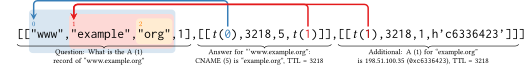

In [8]:
%%tikz -p "$preamble" -S figs/comp-ref-example
\adjustbox{scale=1.5}{\input{figs/comp-ref-example.tex}}

#### Tag 7 (1+0)

To encode with Name _Component Referencing_ using $t = 7$ (1 CBOR header byte + 0 value bytes) as referencing tag, use the following command.

In [9]:
%%bash

git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns checkout name-compr-str-ref
git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns pull

tmux new-session -s "name_comp7_encode" -d \
    "export PATH='${PATH}'; \
     eval \$(pyenv init -); \
     pyenv activate cbor-dns-eval-tbd; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh -t 7 \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_iot.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_name_comp7_encoding_iot.csv.gz; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh -t 7 \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_tranco.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_name_comp7_encoding_tranco.csv.gz"

Switched to branch 'name-compr-str-ref'


Your branch is up to date with 'origin/name-compr-str-ref'.


You can follow this `tmux` session with the `tmux attach -t name_comp7_encode` command.
Depending on your setup, you might get the error message `pyenv: command not found`.
However, as long as the script continues running, everything should be alright.
To kill the tmux session prematurely, use

```sh
tmux send-keys -t "name_comp7_encode" C-c
```

#### Tag 48 (1+1)

To encode with Name _Component Referencing_ using $t = 48$ (1 CBOR header byte + 1 value byte) as referencing tag, use the following command.

In [10]:
%%bash

git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns checkout name-compr-str-ref
git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns pull

tmux new-session -s "name_comp48_encode" -d \
    "export PATH='${PATH}'; \
     eval \$(pyenv init -); \
     pyenv activate cbor-dns-eval-tbd; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh -t 48 \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_iot.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_name_comp48_encoding_iot.csv.gz; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh -t 48 \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_tranco.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_name_comp48_encoding_tranco.csv.gz"

Already on 'name-compr-str-ref'


Your branch is up to date with 'origin/name-compr-str-ref'.


You can follow this `tmux` session with the `tmux attach -t name_comp48_encode` command.
Depending on your setup, you might get the error message `pyenv: command not found`.
However, as long as the script continues running, everything should be alright.
To kill the tmux session prematurely, use

```sh
tmux send-keys -t "name_comp48_encode" C-c
```

### Packed Lite

Packed Lite is a variation of `application/dns+cbor;packed=1` where only the strings, i.e., names, are taken into account for packing.

In [11]:
%%bash

git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns checkout packed-lite
git -C "${DNSCBOR_EVAL_DIR}"/cbor4dns pull

tmux new-session -s "plite_encode" -d \
    "export PATH='${PATH}'; \
     eval \$(pyenv init -); \
     pyenv activate cbor-dns-eval-tbd; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_iot.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_plite_encoding_iot.csv.gz; \
     '${DNSCBOR_EVAL_DIR}'/encode_dns+cbor.sh \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_data_tranco.csv.gz \
        '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_plite_encoding_tranco.csv.gz"

Switched to a new branch 'packed-lite'


Branch 'packed-lite' set up to track remote branch 'packed-lite' from 'origin'.


You can follow this `tmux` session with the `tmux attach -t plite_encode` command.
Depending on your setup, you might get the error message `pyenv: command not found`.
However, as long as the script continues running, everything should be alright.
To kill the tmux session prematurely, use

```sh
tmux send-keys -t "plite_encode" C-c
```

## Compute metrics
This script provides the input CSVs for [the `04_cbor4dns_eval` histograms](../04_cbor4dns_eval.ipynb).
It takes the following arguments.

In [12]:
!"{DNSCBOR_EVAL_DIR}/compute_encoding_metrics.sh" -h

Usage: /home/vagrant/cbor-dns-eval-tbd/04_cbor4dns_eval/compute_encoding_metrics.sh <base format> <input file> <output file> [*-e <excluded formats>]


`<input file`> is the path to a `dns_cbor_*_encoding_*.csv.gz` file as generated above.
`<base format>` is a format for which a `data` and `len` column exists in `<input file>`.
`<output file>` is the path for the resulting `csv.gz` file.
`<excluded formats>` are formats which should not be compared to `<base format>` (`<base format>` is already excluded by default). Multiple formats can be excluded, using multiple `-e` flags.

The resulting CSVs contain the following fields.
For each legal DNS message  (`dns.count.queries == 1`) there is a record.

- `dataset`: The dataset the PCAP was from.
- `pcap`: The path of the PCAP file the frame was from within `./04_cbor4dns_eval/output_datasets/`.
- `frame`: Frame number within the PCAP file.
- `protocol`: Protocol for the DNS message. May be `dns`, `mdns`, or `llmnr` (as well as any other protocol which passes the `dns.count.queries == 1` wireshark filter).
- `msg`: `q` for DNS query or `r` for DNS response.
- `qtype`: The question query type of the DNS message.
- `w_query`: True, when `msg` is `r` and the query was known during encoding, i.e., the question is elided in `application/dns+cbor`.
- For each format that is not the base format or in the excluded formats (the compared format), there are 3 `vs` fields that compare them to the given base format
  - `cr`: Compression ratio $c$<br/>
    \$c = \frac{\text{Base Format Length}}{\text{Compared Format Length}}\$
  - `gain`: Gain $g$<br/>
    \$g = \frac{\text{Base Format Length} - \text{Compared Format Length}}{\text{Base Format Length}}\$
  - `byte savings`: Byte savings $b$<br/>
    \$b = \text{Base Format Length} - \text{Compared Format Length}\$
    
E.g., `application/dns-message vs application/cbor+dns gain` gives the gain of `application/dns+cbor` over `application/dns-message`.

In [13]:
list_code(DNSCBOR_EVAL_DIR / "compute_encoding_metrics.sh")

#!/usr/bin/env bash
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR="$( cd -- "$( dirname -- "${BASH_SOURCE[0]}" )" &> /dev/null && pwd )"

PROCS=$(grep -c '^processor' /proc/cpuinfo)
if [ $PROCS -gt 64 ]; then
    # leave some resources to collegues ;-)
    PROCS=$(( (PROCS * 3) / 4))
fi
EXCLUDE_FORMAT_FILE="$(mktemp)"
while true; do
    case $1 in
    -e)  echo "$2" >> ${EXCLUDE_FORMAT_FILE}
         shift
         shift
         ;;
    *)   break;;
    esac
done

if [ $# -lt 3 ]; then
    echo "Usage: $0 <base format> <input file> <output file> [*-e <excluded formats>]" >&2
    exit 1
fi
BASE_FORMAT="$1"
INPUT_FILE="$2"
OUTPUT_FILE="$3"

"${SCRIPT_DIR}/compute_encoding_metrics.py" --header --exclude-format-file "${EXCLUDE_FORMAT_FILE}" "${BASE_FORMAT}" "${INPUT_FILE}" | \
    pigz > "${OUTPUT_FILE}"

compute_encoding_metrics() {
    "${SCRIPT_DIR}/compute_encoding_metrics.py"  --exclude-format-file "${EXCLUDE_FORMAT_FILE}" "${BASE_FORMAT}" "${INPUT_FILE}" 
}

export SCRIPT_DIR
export EXCLUDE_FORMAT_FILE
export BASE_FORMAT
export INPUT_FILE
export -f compute_encoding_metrics


zcat "${INPUT_FILE}" | \
    parallel --env EXCLUDE -j${PROCS} --pipe --line-buffer compute_encoding_metrics | \
    pigz >> "${OUTPUT_FILE}"

In [14]:
list_code(DNSCBOR_EVAL_DIR / "compute_encoding_metrics.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import concurrent.futures
import csv
import gzip
import multiprocessing
import sys

import bounded_pool_executor

import cbor4dns_utils


WRITER = None


def cr(base_len, compare_len):
    return base_len / compare_len


def gain(base_len, compare_len):
    return 1 - (compare_len / base_len)


def byte_savings(base_len, compare_len):
    return base_len - compare_len


def calculate(row, base_format, compare_formats):
    global WRITER
    try:
        out_row = {
            "dataset": row["dataset"],
            "pcap": row["pcap"],
            "frame": int(row["frame"]),
            "protocol": row["protocol"],
            "msg": row["msg"],
            "qtype": row["qtype"],
            "w_query": row["w_query"]
        }
        has_metrics = False
        for form in compare_formats:
            if row[f"{form} len"] and row[f"{base_format} len"]:
                has_metrics = True
                out_row[f"{base_format} vs {form} cr"] = cr(
                    int(row[f"{base_format} len"]),
                    int(row[f"{form} len"]),
                )
                out_row[f"{base_format} vs {form} gain"] = gain(
                    int(row[f"{base_format} len"]),
                    int(row[f"{form} len"]),
                )
                out_row[f"{base_format} vs {form} byte savings"] = byte_savings(
                    int(row[f"{base_format} len"]),
                    int(row[f"{form} len"]),
                )
        if has_metrics:
            WRITER.writerow(out_row)
    except Exception as e:
        print("Error:", e, "on", row, file=sys.stderr)


def main():
    global WRITER
    parser = argparse.ArgumentParser()
    parser.add_argument(
        metavar="<Base format>",
        dest="base",
        help="Fotmat to compare against"
    )
    parser.add_argument("--header", action="store_true")
    parser.add_argument("--exclude-format-file")
    parser.add_argument(
        metavar="<Encoding CSV file>",
        dest="csv",
        help="CSV file that contains at least one encoding for DNS messages.",
    )
    args = parser.parse_args()

    # use maximum possible size for field size
    max_int = sys.maxsize
    while True:
        try:
            csv.field_size_limit(max_int)
            break
        except OverflowError:
            max_int = (max_int >> 2)

    if args.csv.endswith(".gz"):
        open_func = gzip.open
    else:
        open_func = open
    with open_func(args.csv, "rt", encoding="utf-8") as in_csvfile:
        reader = csv.DictReader(in_csvfile)
        fieldnames = reader.fieldnames
    in_csvfile = sys.stdin
    reader = csv.DictReader(in_csvfile, fieldnames=fieldnames)
    with open(args.exclude_format_file) as exclude_format_file:
        exclude = [l.strip() for l in exclude_format_file.readlines()]
    formats = [
        f.replace(" len", "")
        for f in reader.fieldnames
        if f.endswith(" len") and f not in [
            f"{e} len" for e in (exclude or [])
        ]
    ]
    if args.base not in formats:
        raise ValueError(
            f"Base format \"{args.base}\" not found in CSV header or excluded"
        )
    compare_formats = [f for f in formats if f != args.base]
    cols = [
        f"{args.base} vs {f} {metric}"
        for f in compare_formats
        for metric in ["cr", "gain", "byte savings"]
    ]
    manager = multiprocessing.Manager()
    print(f"Comparing {args.base} vs", file=sys.stderr)
    for form in compare_formats:
        print(f"- {form}", file=sys.stderr)
    out_csvfile = sys.stdout
    WRITER = cbor4dns_utils.FlushableThreadSafeDictWriter(
        out_csvfile,
        manager,
        delimiter=",",
        fieldnames=[
            "dataset", "pcap", "frame", "protocol", "msg", "qtype", "w_query"
        ] + cols,
    )
    if args.header:
        WRITER.writeheader()
        return
   

In [15]:
list_code(DNSCBOR_EVAL_DIR / "compute_encoding_metrics.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import concurrent.futures
import csv
import gzip
import multiprocessing
import sys

import bounded_pool_executor

import cbor4dns_utils


WRITER = None


def cr(base_len, compare_len):
    return base_len / compare_len


def gain(base_len, compare_len):
    return 1 - (compare_len / base_len)


def byte_savings(base_len, compare_len):
    return base_len - compare_len


def calculate(row, base_format, compare_formats):
    global WRITER
    try:
        out_row = {
            "dataset": row["dataset"],
            "pcap": row["pcap"],
            "frame": int(row["frame"]),
            "protocol": row["protocol"],
            "msg": row["msg"],
            "qtype": row["qtype"],
            "w_query": row["w_query"]
        }
        has_metrics = False
        for form in compare_formats:
            if row[f"{form} len"] and row[f"{base_format} len"]:
                has_metrics = True
                out_row[f"{base_format} vs {form} cr"] = cr(
                    int(row[f"{base_format} len"]),
                    int(row[f"{form} len"]),
                )
                out_row[f"{base_format} vs {form} gain"] = gain(
                    int(row[f"{base_format} len"]),
                    int(row[f"{form} len"]),
                )
                out_row[f"{base_format} vs {form} byte savings"] = byte_savings(
                    int(row[f"{base_format} len"]),
                    int(row[f"{form} len"]),
                )
        if has_metrics:
            WRITER.writerow(out_row)
    except Exception as e:
        print("Error:", e, "on", row, file=sys.stderr)


def main():
    global WRITER
    parser = argparse.ArgumentParser()
    parser.add_argument(
        metavar="<Base format>",
        dest="base",
        help="Fotmat to compare against"
    )
    parser.add_argument("--header", action="store_true")
    parser.add_argument("--exclude-format-file")
    parser.add_argument(
        metavar="<Encoding CSV file>",
        dest="csv",
        help="CSV file that contains at least one encoding for DNS messages.",
    )
    args = parser.parse_args()

    # use maximum possible size for field size
    max_int = sys.maxsize
    while True:
        try:
            csv.field_size_limit(max_int)
            break
        except OverflowError:
            max_int = (max_int >> 2)

    if args.csv.endswith(".gz"):
        open_func = gzip.open
    else:
        open_func = open
    with open_func(args.csv, "rt", encoding="utf-8") as in_csvfile:
        reader = csv.DictReader(in_csvfile)
        fieldnames = reader.fieldnames
    in_csvfile = sys.stdin
    reader = csv.DictReader(in_csvfile, fieldnames=fieldnames)
    with open(args.exclude_format_file) as exclude_format_file:
        exclude = [l.strip() for l in exclude_format_file.readlines()]
    formats = [
        f.replace(" len", "")
        for f in reader.fieldnames
        if f.endswith(" len") and f not in [
            f"{e} len" for e in (exclude or [])
        ]
    ]
    if args.base not in formats:
        raise ValueError(
            f"Base format \"{args.base}\" not found in CSV header or excluded"
        )
    compare_formats = [f for f in formats if f != args.base]
    cols = [
        f"{args.base} vs {f} {metric}"
        for f in compare_formats
        for metric in ["cr", "gain", "byte savings"]
    ]
    manager = multiprocessing.Manager()
    print(f"Comparing {args.base} vs", file=sys.stderr)
    for form in compare_formats:
        print(f"- {form}", file=sys.stderr)
    out_csvfile = sys.stdout
    WRITER = cbor4dns_utils.FlushableThreadSafeDictWriter(
        out_csvfile,
        manager,
        delimiter=",",
        fieldnames=[
            "dataset", "pcap", "frame", "protocol", "msg", "qtype", "w_query"
        ] + cols,
    )
    if args.header:
        WRITER.writeheader()
        return
   

In [16]:
%%bash

tmux new-session -s "compute_metrics" -d \
    "for dataset in iot tranco; do \
        for enc in classic name_comp7 name_comp48 plite; do \
            echo \"==== Calculating metrics for \${enc} of \${dataset} ====\"; \
            '${DNSCBOR_EVAL_DIR}'/compute_encoding_metrics.py 'application/dns-message' \
                '${DNSCBOR_EVAL_DIR}'/output_datasets/dns_cbor_\${enc}_encoding_\${dataset}.csv.gz \
                | pigz > "${DNSCBOR_EVAL_DIR}"/output_datasets/dns_cbor_\${enc}_metric_\${dataset}.csv.gz; \
        done; \
    done"